In [1]:
import zipfile

def unzip_file(zip_path, extract_to):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
    print(f"Extracted {zip_path} to {extract_to}")

# Unzip each zip file to folders with the same base name
unzip_file("durva.zip", "durva")
unzip_file("other.zip", "other")

Extracted durva.zip to durva
Extracted other.zip to other


In [2]:
import os

def rename_images(folder_path, prefix):
    files = sorted(os.listdir(folder_path))
    for idx, filename in enumerate(files, start=1):
        ext = os.path.splitext(filename)[1]
        new_filename = f"{prefix}_{idx}{ext}"
        src = os.path.join(folder_path, filename)
        dst = os.path.join(folder_path, new_filename)
        os.rename(src, dst)
        print(f"Renamed {filename} --> {new_filename}")

# Rename images in extracted directories
rename_images("durva", "durva")
rename_images("other", "other")

Renamed 1_79355f0a-53ba-4f26-bee1-8259b5994e9d.webp --> durva_1.webp
Renamed 1f1af67132210619fa5f38c5232d7ad9.jpg --> durva_2.jpg
Renamed 21aff4145b916d6b8941b1c71ae413c2.jpg --> durva_3.jpg
Renamed 47bef12a20b407e21de9c5156489b07c.jpg --> durva_4.jpg
Renamed 514355aab7ee0211655f1eae0cf80b30.jpg --> durva_5.jpg
Renamed 57e713b9a6fa787126e9aac1760622b8.jpg --> durva_6.jpg
Renamed 61jz9tR-qnL.jpg --> durva_7.jpg
Renamed 6833ffbcfc0fb3b76a6f6bf15e966f46.jpg --> durva_8.jpg
Renamed 710IaYZfCTL._UF1000,1000_QL80_.jpg --> durva_9.jpg
Renamed 71JMiudCikL._UF1000,1000_QL80_.jpg --> durva_10.jpg
Renamed 80a44fe883c88a6a30da08fa1d9d1d32.jpg --> durva_11.jpg
Renamed 81EdJEo6foL._UF1000,1000_QL80_.jpg --> durva_12.jpg
Renamed Durva-Ghaas.avif --> durva_13.avif
Renamed Durva-Grass-main (1).png --> durva_14.png
Renamed Durva-Grass-main.png --> durva_15.png
Renamed Durva-grass.webp --> durva_16.webp
Renamed IMG-20250917-WA0018.jpg --> durva_17.jpg
Renamed IMG-20250918-WA0021 (1).jpg --> durva_18.jpg


In [3]:
import os
from PIL import Image
import pillow_avif  # Add this line after installing pillow-avif-plugin

def convert_images_to_jpg(folder_path):
    files = os.listdir(folder_path)
    for filename in files:
        file_path = os.path.join(folder_path, filename)
        ext = os.path.splitext(filename)[1].lower()
        if ext != ".jpg" and ext != ".jpeg":
            try:
                # Open image with AVIF support
                img = Image.open(file_path).convert('RGB')
                # Create new filename with .jpg extension
                new_filename = os.path.splitext(filename)[0] + ".jpg"
                new_file_path = os.path.join(folder_path, new_filename)
                # Save as JPG
                img.save(new_file_path, "JPEG")
                # Remove old file
                os.remove(file_path)
                print(f"Converted and saved {filename} as {new_filename}")
            except Exception as e:
                print(f"Skipping {filename}: cannot open or convert image ({e})")
        else:
            print(f"{filename} is already in JPG format.")

# Check and convert images in both folders
convert_images_to_jpg("durva")
convert_images_to_jpg("other")

Converted and saved durva_1.webp as durva_1.jpg
durva_10.jpg is already in JPG format.
durva_100.jpg is already in JPG format.
durva_101.jpg is already in JPG format.
durva_102.jpg is already in JPG format.
durva_103.jpg is already in JPG format.
durva_104.jpg is already in JPG format.
durva_105.jpg is already in JPG format.
durva_106.jpg is already in JPG format.
durva_107.jpg is already in JPG format.
durva_108.jpg is already in JPG format.
durva_109.jpg is already in JPG format.
durva_11.jpg is already in JPG format.
Converted and saved durva_110.webp as durva_110.jpg
Converted and saved durva_111.webp as durva_111.jpg
Converted and saved durva_112.webp as durva_112.jpg
Converted and saved durva_113.webp as durva_113.jpg
Converted and saved durva_114.webp as durva_114.jpg
durva_115.jpg is already in JPG format.
Converted and saved durva_116.webp as durva_116.jpg
durva_117.jpg is already in JPG format.
durva_118.jpg is already in JPG format.
durva_119.jpg is already in JPG format.
du

In [4]:
import shutil
import os

# Define source folders
durva_folder = "durva"
other_folder = "other"

# Define combined folder and class subfolders
combined_folder = "combined_data"
durva_class_folder = os.path.join(combined_folder, "class1")
other_class_folder = os.path.join(combined_folder, "class2")

# Create folders if they don't exist
os.makedirs(durva_class_folder, exist_ok=True)
os.makedirs(other_class_folder, exist_ok=True)

# Move durva images to class1 folder
for file in os.listdir(durva_folder):
    shutil.move(os.path.join(durva_folder, file), durva_class_folder)

# Move other images to class2 folder
for file in os.listdir(other_folder):
    shutil.move(os.path.join(other_folder, file), other_class_folder)

print("Images combined into 'combined_data' folder with class subfolders.")

Images combined into 'combined_data' folder with class subfolders.


In [5]:
import os
from PIL import Image

def resize_images_in_folder(folder_path, target_size=(224, 224)):
    for filename in os.listdir(folder_path):
        if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
            file_path = os.path.join(folder_path, filename)
            img = Image.open(file_path).convert('RGB')
            img_resized = img.resize(target_size, Image.LANCZOS)
            img_resized.save(file_path)
            print(f"Resized {filename} to {target_size}")

resize_images_in_folder("combined_data/class1")
resize_images_in_folder("combined_data/class2")

Resized durva_1.jpg to (224, 224)
Resized durva_10.jpg to (224, 224)
Resized durva_100.jpg to (224, 224)
Resized durva_101.jpg to (224, 224)
Resized durva_102.jpg to (224, 224)
Resized durva_103.jpg to (224, 224)
Resized durva_104.jpg to (224, 224)
Resized durva_105.jpg to (224, 224)
Resized durva_106.jpg to (224, 224)
Resized durva_107.jpg to (224, 224)
Resized durva_108.jpg to (224, 224)
Resized durva_109.jpg to (224, 224)
Resized durva_11.jpg to (224, 224)
Resized durva_110.jpg to (224, 224)
Resized durva_111.jpg to (224, 224)
Resized durva_112.jpg to (224, 224)
Resized durva_113.jpg to (224, 224)
Resized durva_114.jpg to (224, 224)
Resized durva_115.jpg to (224, 224)
Resized durva_116.jpg to (224, 224)
Resized durva_117.jpg to (224, 224)
Resized durva_118.jpg to (224, 224)
Resized durva_119.jpg to (224, 224)
Resized durva_12.jpg to (224, 224)
Resized durva_120.jpg to (224, 224)
Resized durva_121.jpg to (224, 224)
Resized durva_122.jpg to (224, 224)
Resized durva_123.jpg to (224, 22

In [6]:
import shutil

# Source folder with original images
source_folder = "combined_data"
# Destination folder to keep original images as backup
backup_folder = "combined_data_with_background"

# Copy entire directory tree to backup folder
shutil.copytree(source_folder, backup_folder)

print(f"Copied folder {source_folder} to {backup_folder} to keep original images")

Copied folder combined_data to combined_data_with_background to keep original images


In [7]:
import os
from rembg import remove
from PIL import Image

def remove_bg_folder(folder):
    for fname in os.listdir(folder):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            fpath = os.path.join(folder, fname)
            img = Image.open(fpath)
            out = remove(img)
            # Save with same base name but .png extension
            new_fpath = os.path.splitext(fpath)[0] + ".png"
            out.save(new_fpath)
            # Remove original image (with background)
            os.remove(fpath)
            print(f"Replaced {fname} with background removed image.")

remove_bg_folder("combined_data/class1")
remove_bg_folder("combined_data/class2")

Replaced durva_1.jpg with background removed image.
Replaced durva_10.jpg with background removed image.
Replaced durva_100.jpg with background removed image.
Replaced durva_101.jpg with background removed image.
Replaced durva_102.jpg with background removed image.
Replaced durva_103.jpg with background removed image.
Replaced durva_104.jpg with background removed image.
Replaced durva_105.jpg with background removed image.
Replaced durva_106.jpg with background removed image.
Replaced durva_107.jpg with background removed image.
Replaced durva_108.jpg with background removed image.
Replaced durva_109.jpg with background removed image.
Replaced durva_11.jpg with background removed image.
Replaced durva_110.jpg with background removed image.
Replaced durva_111.jpg with background removed image.
Replaced durva_112.jpg with background removed image.
Replaced durva_113.jpg with background removed image.
Replaced durva_114.jpg with background removed image.
Replaced durva_115.jpg with back

In [8]:
import os

def count_images(folder_path):
    count = 0
    for root, _, files in os.walk(folder_path):
        for filename in files:
            if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                count += 1
    return count

combined_data_count = count_images("combined_data")
combined_data_with_bg_count = count_images("combined_data_with_background")

print(f"Number of images in 'combined_data': {combined_data_count}")
print(f"Number of images in 'combined_data_with_background': {combined_data_with_bg_count}")

Number of images in 'combined_data': 400
Number of images in 'combined_data_with_background': 400


In [9]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

data_dir = "combined_data"  # Your folder with class1 and class2 subfolders
img_height, img_width = 224, 224
batch_size = 32

# Create data generators for training and validation with image augmentation
datagen = ImageDataGenerator(
    validation_split=0.2,  # 20% for validation
    rescale=1./255,        # normalize pixel values
    horizontal_flip=True,  # example augmentation
    rotation_range=20,
    zoom_range=0.1
)

train_generator = datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

validation_generator = datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 320 images belonging to 2 classes.
Found 80 images belonging to 2 classes.


In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

num_classes = 2  # class1 and class2

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(img_height, img_width, 3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

C:\Users\shrey\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 186624)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      23,888,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │             258 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,907,650 (91.20 MB)

 Trainable params: 23,907,650 (91.20 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
epochs = 10
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=epochs
)

C:\Users\shrey\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.5156 - loss: 1.0442 - val_accuracy: 0.6625 - val_loss: 0.6857
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 746ms/step - accuracy: 0.5250 - loss: 0.6950 - val_accuracy: 0.4875 - val_loss: 0.6661
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 695ms/step - accuracy: 0.5719 - loss: 0.6768 - val_accuracy: 0.7125 - val_loss: 0.6596
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 723ms/step - accuracy: 0.5375 - loss: 0.6766 - val_accuracy: 0.6500 - val_loss: 0.6690
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 715ms/step - accuracy: 0.6438 - loss: 0.6516 - val_accuracy: 0.7125 - val_loss: 0.6023
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 707ms/step - accuracy: 0.6187 - loss: 0.6345 - val_accuracy: 0.6875 - val_loss: 0.5945
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 701ms/step - accuracy: 0.6406 - loss: 0.6305 - val_accuracy: 0.7500 - val_loss: 0.5925
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 779ms/step - accuracy: 0.6562 - loss: 0.6310 - val_accuracy: 0.63

In [12]:
# Evaluate on validation set (if any)
loss, accuracy = model.evaluate(validation_generator)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

# Save model
model.save("grass_type_classifier.h5")

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 324ms/step - accuracy: 0.6500 - loss: 0.6579


Validation Loss: 0.6579
Validation Accuracy: 0.6500


In [13]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

num_classes = 2  # Update to match your dataset
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze base

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 2)                   │             258 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,422,210 (9.24 MB)

 Trainable params: 164,226 (641.51 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [14]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, verbose=1)

In [15]:
epochs = 20
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=epochs,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.5406 - loss: 0.8639 - val_accuracy: 0.6500 - val_loss: 0.7513 - learning_rate: 0.0010
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 817ms/step - accuracy: 0.6031 - loss: 0.7739 - val_accuracy: 0.6250 - val_loss: 0.6390 - learning_rate: 0.0010
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 806ms/step - accuracy: 0.6750 - loss: 0.6048 - val_accuracy: 0.6000 - val_loss: 0.6054 - learning_rate: 0.0010
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 877ms/step - accuracy: 0.6625 - loss: 0.5796 - val_accuracy: 0.7000 - val_loss: 0.5842 - learning_rate: 0.0010
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 825ms/step - accuracy: 0.7219 - loss: 0.5466 - val_accuracy: 0.6250 - val_loss: 0.5953 - learning_rate: 0.0010
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 850ms/step - accuracy: 0.7188 - loss: 0.5381 - val_accuracy: 0.7000 - val_loss: 0.5723 - learning_rate: 0.0010
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 826ms/step - accuracy: 0.7594 - loss: 0.5156 - va

In [16]:
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])
fine_tune_epochs = 10
history_fine = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=fine_tune_epochs,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.5719 - loss: 0.9513 - val_accuracy: 0.6875 - val_loss: 0.5953 - learning_rate: 1.0000e-05
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 644ms/step - accuracy: 0.6455 - loss: 0.7287
Epoch 2: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 814ms/step - accuracy: 0.6062 - loss: 0.7608 - val_accuracy: 0.7000 - val_loss: 0.5936 - learning_rate: 1.0000e-05
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 813ms/step - accuracy: 0.5750 - loss: 0.7542 - val_accuracy: 0.7625 - val_loss: 0.5914 - learning_rate: 2.0000e-06
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 626ms/step - accuracy: 0.5910 - loss: 0.6574
Epoch 4: ReduceLROnPlateau reducing learning rate to 3.999999989900971e-07.
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 796ms/step - accuracy: 0.5875 - loss: 0.7128 - val_accuracy: 0.7250 - val_loss: 0.5910 - learning_rate: 2.0000e-06
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 811ms/step - accuracy: 0.5969 - l

In [17]:
import numpy as np

validation_generator.reset()
preds = model.predict(validation_generator)
pred_labels = np.argmax(preds, axis=1)
true_labels = validation_generator.classes

misclassified_indices = np.where(pred_labels != true_labels)[0]
misclassified_files = [validation_generator.filenames[i] for i in misclassified_indices]
print("Misclassified images:", misclassified_files)

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 863ms/step
Misclassified images: ['class1\\durva_103.png', 'class1\\durva_104.png', 'class1\\durva_105.png', 'class1\\durva_11.png', 'class1\\durva_115.png', 'class1\\durva_121.png', 'class1\\durva_123.png', 'class1\\durva_124.png', 'class1\\durva_126.png', 'class1\\durva_128.png', 'class1\\durva_13.png', 'class1\\durva_130.png', 'class1\\durva_132.png', 'class1\\durva_134.png', 'class2\\other_100.png', 'class2\\other_102.png', 'class2\\other_104.png', 'class2\\other_107.png', 'class2\\other_11.png', 'class2\\other_111.png', 'class2\\other_12.png', 'class2\\other_121.png', 'class2\\other_122.png', 'class2\\other_127.png', 'class2\\other_131.png']


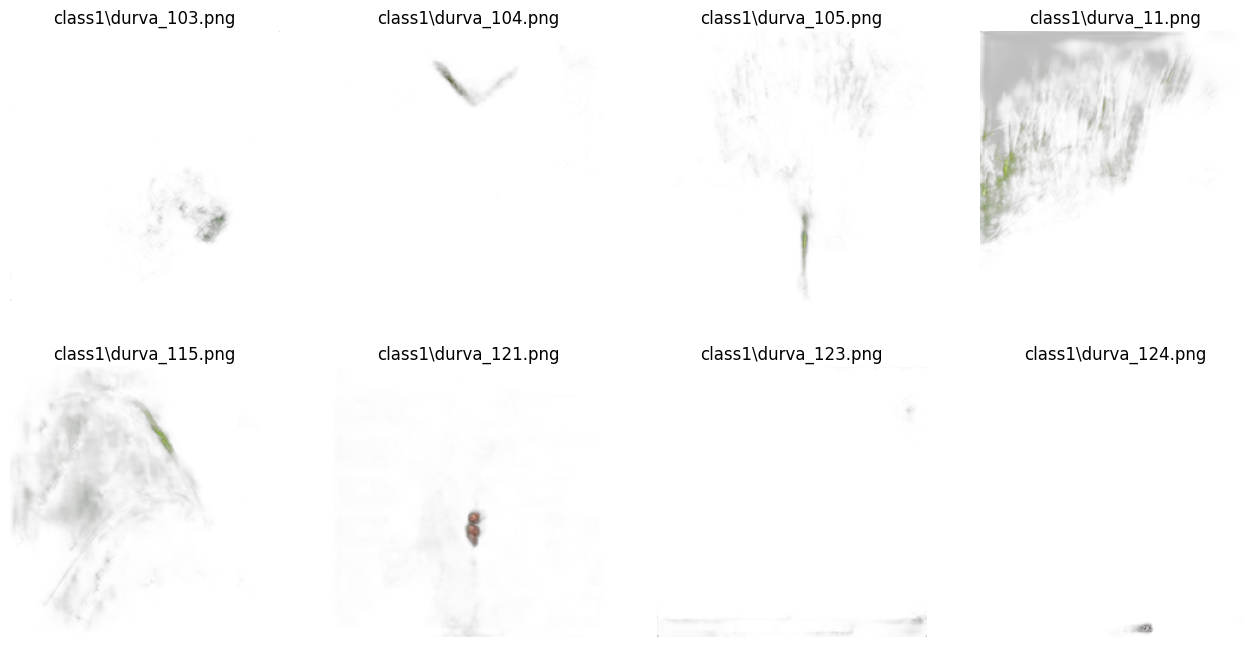

In [18]:
import matplotlib.pyplot as plt
import os
from PIL import Image

misclassified_folder = 'combined_data'  # or the root where class1/class2 are
num_images_to_show = 8

plt.figure(figsize=(16, 8))
for idx, file in enumerate(misclassified_files[:num_images_to_show]):
    img = Image.open(os.path.join(misclassified_folder, file))
    plt.subplot(2, 4, idx+1)
    plt.imshow(img)
    plt.title(file)
    plt.axis('off')
plt.show()

In [19]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

cm = confusion_matrix(true_labels, pred_labels)
print("Confusion Matrix:\n", cm)

print("Classification Report:\n", classification_report(true_labels, pred_labels))

Confusion Matrix:
 [[26 14]
 [11 29]]
Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.65      0.68        40
           1       0.67      0.72      0.70        40

    accuracy                           0.69        80
   macro avg       0.69      0.69      0.69        80
weighted avg       0.69      0.69      0.69        80



In [20]:
# Unfreeze the top 20 layers for fine-tuning
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

fine_tune_epochs = 10
history_fine = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=fine_tune_epochs,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.5906 - loss: 0.7844 - val_accuracy: 0.7500 - val_loss: 0.5725 - learning_rate: 1.0000e-05
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 628ms/step - accuracy: 0.6152 - loss: 0.6834
Epoch 2: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 801ms/step - accuracy: 0.6281 - loss: 0.6584 - val_accuracy: 0.7500 - val_loss: 0.5932 - learning_rate: 1.0000e-05
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 834ms/step - accuracy: 0.6156 - loss: 0.6922 - val_accuracy: 0.7375 - val_loss: 0.5851 - learning_rate: 2.0000e-06
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 647ms/step - accuracy: 0.6694 - loss: 0.6251
Epoch 4: ReduceLROnPlateau reducing learning rate to 3.999999989900971e-07.
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 819ms/step - accuracy: 0.6719 - loss: 0.5963 - val_accuracy: 0.6875 - val_loss: 0.6188 - learning_rate: 2.0000e-06
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 835ms/step - accuracy: 0.6062 - lo

In [21]:
datagen = ImageDataGenerator(
    validation_split=0.2,
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.15,
    zoom_range=0.2,
    channel_shift_range=30.0,
    brightness_range=[0.8,1.2],
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest'
)
# Rerun flow_from_directory for train/validation sets as before

In [22]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

labels = train_generator.classes
class_weights = compute_class_weight(class_weight='balanced',
                                    classes=np.unique(labels),
                                    y=labels)
class_weights_dict = {i : class_weights[i] for i in range(len(class_weights))}

# Add to model.fit()
model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=epochs,
    class_weight=class_weights_dict,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 13s 881ms/step - accuracy: 0.5938 - loss: 0.7529 - val_accuracy: 0.6875 - val_loss: 0.5885 - learning_rate: 4.0000e-07
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 636ms/step - accuracy: 0.6141 - loss: 0.7015
Epoch 2: ReduceLROnPlateau reducing learning rate to 8.00000009348878e-08.
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 817ms/step - accuracy: 0.5906 - loss: 0.7111 - val_accuracy: 0.7000 - val_loss: 0.6162 - learning_rate: 4.0000e-07
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 816ms/step - accuracy: 0.6094 - loss: 0.7217 - val_accuracy: 0.7375 - val_loss: 0.5785 - learning_rate: 8.0000e-08
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 656ms/step - accuracy: 0.6460 - loss: 0.6492
Epoch 4: ReduceLROnPlateau reducing learning rate to 1.5999999902760466e-08.
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 826ms/step - accuracy: 0.6031 - loss: 0.7066 - val_accuracy: 0.7000 - val_loss: 0.6000 - learning_rate: 8.0000e-08
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 840ms/step - accuracy: 0.6281 - 

In [23]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, verbose=1)

In [24]:
# Assuming 'model' is your compiled model and 'train_generator', 'validation_generator' are your datasets

epochs = 20  # You can adjust number of epochs

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=epochs,
    callbacks=[early_stop, reduce_lr]  # Use the callbacks here
)

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.6313 - loss: 0.6919 - val_accuracy: 0.7000 - val_loss: 0.6057 - learning_rate: 1.6000e-08
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.6031 - loss: 0.7160 - val_accuracy: 0.7500 - val_loss: 0.5579 - learning_rate: 1.6000e-08
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.5813 - loss: 0.7216 - val_accuracy: 0.7375 - val_loss: 0.6065 - learning_rate: 1.6000e-08
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.5406 - loss: 0.7354 - val_accuracy: 0.7375 - val_loss: 0.5728 - learning_rate: 1.6000e-08
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6075 - loss: 0.6693 
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.7999998642467285e-09.
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.5844 - loss: 0.7386 - val_accuracy: 0.7000 - val_loss: 0.5905 - learning_rate: 1.6000e-08
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.6031 - loss: 0.7

In [25]:
# Print training and validation accuracy and loss for each epoch
for epoch in range(len(history.history['accuracy'])):
    print(f"Epoch {epoch+1}:")
    print(f"  Train Accuracy: {history.history['accuracy'][epoch]:.4f}, Validation Accuracy: {history.history['val_accuracy'][epoch]:.4f}")
    print(f"  Train Loss: {history.history['loss'][epoch]:.4f}, Validation Loss: {history.history['val_loss'][epoch]:.4f}")

Epoch 1:
  Train Accuracy: 0.6313, Validation Accuracy: 0.7000
  Train Loss: 0.6919, Validation Loss: 0.6057
Epoch 2:
  Train Accuracy: 0.6031, Validation Accuracy: 0.7500
  Train Loss: 0.7160, Validation Loss: 0.5579
Epoch 3:
  Train Accuracy: 0.5813, Validation Accuracy: 0.7375
  Train Loss: 0.7216, Validation Loss: 0.6065
Epoch 4:
  Train Accuracy: 0.5406, Validation Accuracy: 0.7375
  Train Loss: 0.7354, Validation Loss: 0.5728
Epoch 5:
  Train Accuracy: 0.5844, Validation Accuracy: 0.7000
  Train Loss: 0.7386, Validation Loss: 0.5905
Epoch 6:
  Train Accuracy: 0.6031, Validation Accuracy: 0.7250
  Train Loss: 0.7072, Validation Loss: 0.5586
Epoch 7:
  Train Accuracy: 0.6062, Validation Accuracy: 0.7375
  Train Loss: 0.7218, Validation Loss: 0.5632


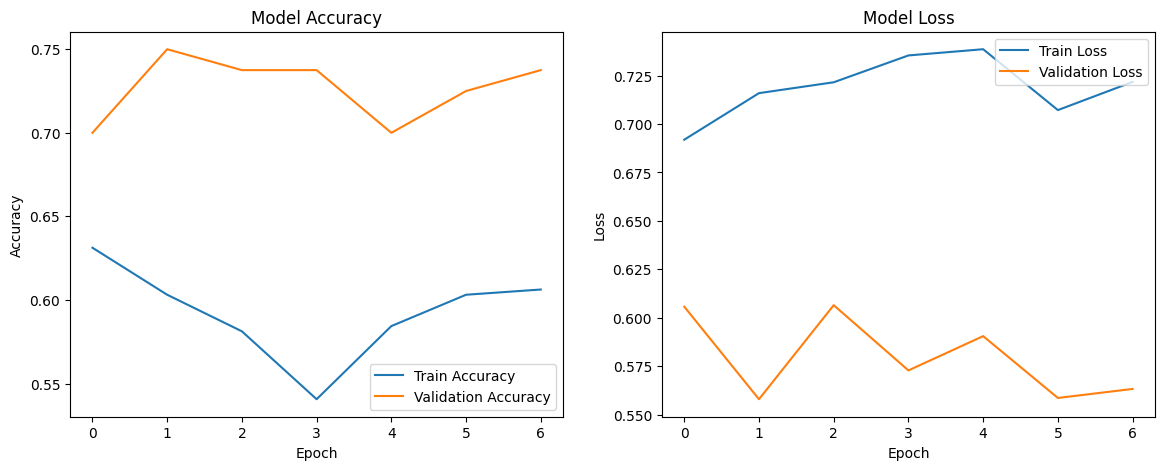

In [26]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    # Plot training & validation accuracy values
    plt.figure(figsize=(14,5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')

    plt.show()

# Call this function with your training history from model.fit()
plot_training_history(history)

In [27]:
# Unfreeze top layers for fine-tuning
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

fine_tune_history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.6187 - loss: 0.6684 - val_accuracy: 0.7000 - val_loss: 0.5886 - learning_rate: 1.0000e-05
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.6500 - loss: 0.6205 - val_accuracy: 0.7125 - val_loss: 0.5851 - learning_rate: 1.0000e-05
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6451 - loss: 0.6082 
Epoch 3: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.6781 - loss: 0.5721 - val_accuracy: 0.7250 - val_loss: 0.6223 - learning_rate: 1.0000e-05
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.6812 - loss: 0.5744 - val_accuracy: 0.7250 - val_loss: 0.5758 - learning_rate: 3.0000e-06
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.7031 - loss: 0.5344 - val_accuracy: 0.7250 - val_loss: 0.6111 - learning_rate: 3.0000e-06


In [28]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

validation_generator.reset()
preds = model.predict(validation_generator)
pred_labels = np.argmax(preds, axis=1)
true_labels = validation_generator.classes

cm = confusion_matrix(true_labels, pred_labels)
print("Confusion Matrix:\n", cm)

target_names = list(validation_generator.class_indices.keys())
print("Classification Report:\n", classification_report(true_labels, pred_labels, target_names=target_names))

3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step   
Confusion Matrix:
 [[32  8]
 [10 30]]
Classification Report:
               precision    recall  f1-score   support

      class1       0.76      0.80      0.78        40
      class2       0.79      0.75      0.77        40

    accuracy                           0.78        80
   macro avg       0.78      0.78      0.77        80
weighted avg       0.78      0.78      0.77        80



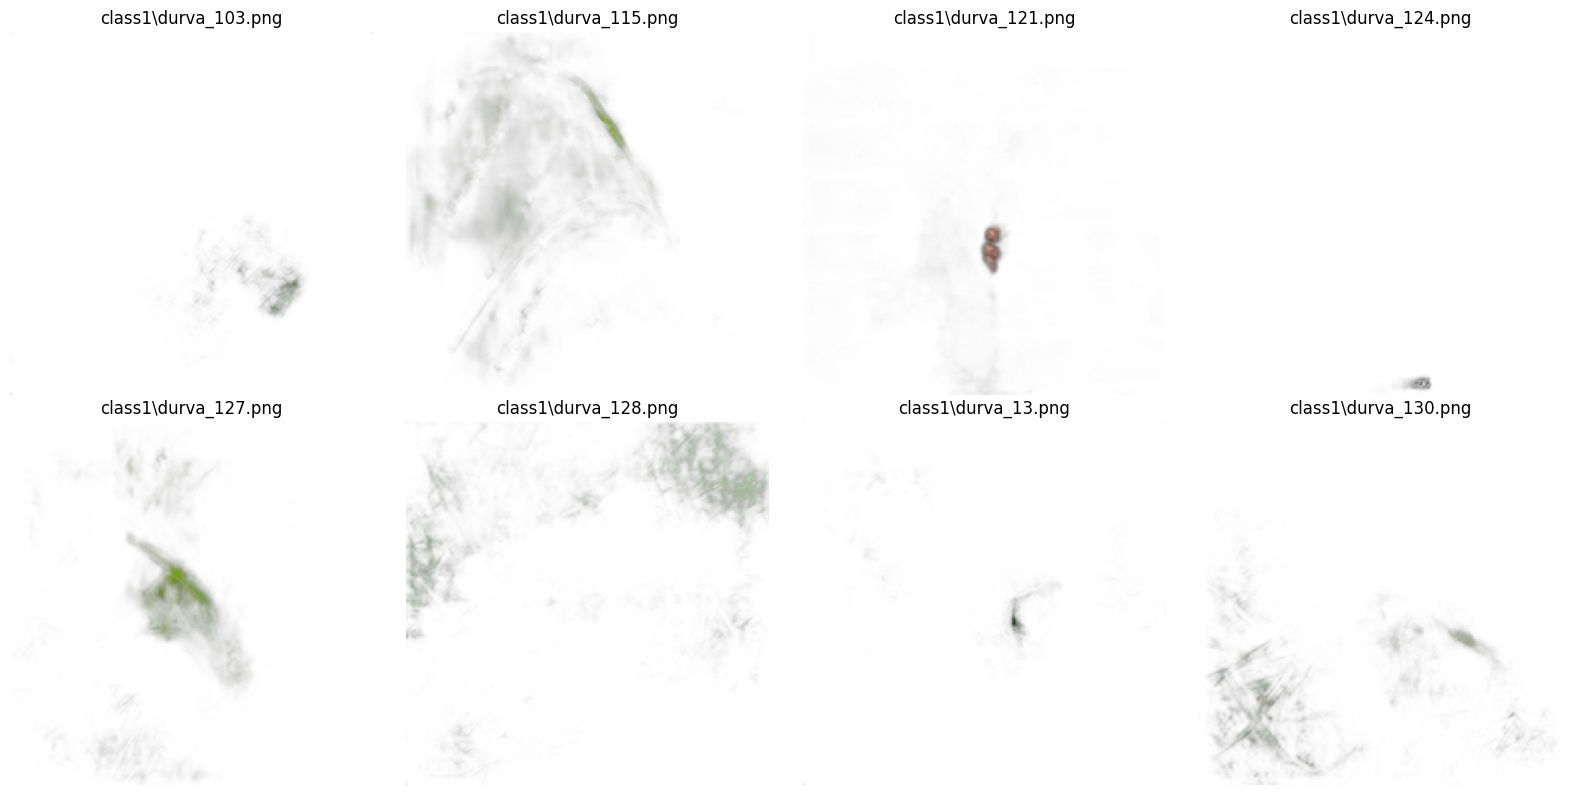

In [29]:
import matplotlib.pyplot as plt
import os
from PIL import Image

misclassified_indices = np.where(pred_labels != true_labels)[0]
misclassified_files = [validation_generator.filenames[i] for i in misclassified_indices]

plt.figure(figsize=(16, 8))
for idx, file in enumerate(misclassified_files[:8]):
    img = Image.open(os.path.join('combined_data', file))
    plt.subplot(2, 4, idx+1)
    plt.imshow(img)
    plt.title(file)
    plt.axis('off')
plt.tight_layout()
plt.show()

In [30]:
model.save("grass_classifier_final.h5")  # or use .keras for the SavedModel format

In [31]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = "dhruv-2.webp"
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)
predicted_class = np.argmax(prediction, axis=1)[0]
class_labels = list(validation_generator.class_indices.keys())
print("Predicted Class:", class_labels[predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Predicted Class: class1


In [32]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = "pngtree-a-green-grass-png-image_13678061.png"
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)
predicted_class = np.argmax(prediction, axis=1)[0]
class_labels = list(validation_generator.class_indices.keys())
print("Predicted Class:", class_labels[predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step


C:\Users\shrey\AppData\Roaming\Python\Python313\site-packages\PIL\Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Predicted Class: class1
